In [ ]:
#%pip install rpy2

Defaulting to user installation because normal site-packages is not writeable

   ---------- ----------------------------- 1/4 [rpy2-rinterface]
   ---------- ----------------------------- 1/4 [rpy2-rinterface]
   ---------- ----------------------------- 1/4 [rpy2-rinterface]
   -------------------- ------------------- 2/4 [rpy2-robjects]
   -------------------- ------------------- 2/4 [rpy2-robjects]
   -------------------- ------------------- 2/4 [rpy2-robjects]
   ---------------------------------------- 4/4 [rpy2]

Note: you may need to restart the kernel to use updated packages.


In [1]:
import rpy2.robjects as robjects
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri

import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


In [2]:
pd.set_option("display.max_columns", None)

In [3]:
readRDS = robjects.r['readRDS']

In [6]:
survey_r = readRDS(r"C:\Users\Peter\OneDrive\Desktop\Code and Projects\ECO1465\Replication Package\Datasets\Survey\survey.rds")

In [7]:
survey_r

ResponseId,treatment,matchTreatment,...,F_modifiedViews,F_withoutLastControl,F_startPOSIX
'R_0005Pj...,Liberal,Pro,...,NA_integer_,NA,NA_charac...
'R_0006ze...,Liberal,Counter,,1,1,2018-04-2...
'R_000QQG...,Liberal,Pro,,NA_integer_,NA,...
'R_000QuL...,Control,Control,,NA_integer_,1,2018-05-2...
...,...,...,,...,...,2018-05-1...
'R_zfiOvl...,Conse...,Counter,,0,1,2018-04-1...
'R_zfj2X1...,Control,Control,,1,1,2018-04-2...
'R_zflZX2...,Control,Control,,1,1,
'R_zfoOiB...,Conse...,Pro,,NA_integer_,NA,


In [8]:
with localconverter(robjects.default_converter + pandas2ri.converter):
    survey = robjects.conversion.rpy2py(survey_r)

In [12]:
survey

,ResponseId,treatment,matchTreatment,treatIdeo,control,potentialText,primaryOutlets,comply,newLikesNum,tookFollowup,have14DaysPosts,installTwoWeeks,have14DaysLikes,validExtAndShared,validHisOneWeek,minHistoryRelative,maxTimeExt,maxDiffPostsDay,mobile,politicsAd,follow,followAboveMed,thermo_Rep,thermo_Dem,empathy_Rep,empathy_Dem,certain,certainAboveEqMed,selfReportedLikesNum,slant_Rep,slant_Dem,zipReside,registered,personality_1,personality_2,personality_3,personality_4,personality_5,personality_6,personality_7,personality_8,personality_9,personality_10,immigration,daca,immigrationWorry,thermo_Trump,thermo_TrumpHave,thermo_TrumpWM,thermo_Local,mostNews,mostNewsSM,accessWebsites,crtA,crtB,ideoLeaning,ideoLeaningF,startPOSIX,democrat,republican,independent,ideologyN,thermo_Diff,thermo_DiffAboveEqMed,thermo_DiffHave,thermo_DiffWM,age,ageAboveMed,ageHave,ageWM,female,ideologyF,partyAllF,trumpF,genderF,ageSqWM,immigrationWorryF,MuellerFairF,obstructF,repF,absIdeology,empathyDifficult_Diff,empathyDifficult_DiffHave,empathyDifficult_DiffWM,echoChamber,echoChamberAboveEqMed,openessPersonality,openessPersonalityAboveEqMed,seenCounterAnyShare,seenCounterAnyShareAboveEqMed,initialLikesNum,countInitialNewsLikes,countInitialNewsLikesAboveMed,meanInitialSlant,absInitialSlant,postsInitialAccess,absIdeoAboveEqMed,meanSeenAboveMed,meanDistSlantUnderMed,consIdeology,crtScoreAboveEqMed,clickLinks_Mobile,clickLinks_PC,party7,genericBallotF,thermo_Own,thermo_Opposing,empathyDifficult_Own,empathyDifficult_Opposing,objective,voteSupport2016F,ageSq,rosensteinF,Q_SocialSource,askExtension,F_approve,F_approve_ScaleS,F_favorable_McCabe,F_favorable_McCabe_Op_ScaleS,F_favorable_Hogg,F_favorable_Hogg_Op_ScaleS,F_favorable_Mueller,F_favorable_Mueller_Op_ScaleS,F_favorable_Daniels,F_favorable_Daniels_Op_ScaleS,F_favorable_Bolton,F_favorable_Bolton_Op_ScaleS,F_favorable_Pruitt,F_favorable_Pruitt_Op_ScaleS,F_favorable_Cohen,F_favorable_Cohen_Op_ScaleS,F_favorable_Clinton,F_favorable_Clinton_Op_ScaleS,F_favOrg_NRA,F_favOrg_NRA_Op_ScaleS,F_favOrg_March,F_favOrg_March_Op_ScaleS,F_favOrg_California,F_favOrg_California_Op_ScaleS,F_favOrg_FBI,F_favOrg_FBI_Op_ScaleS,F_mccabe_summary,F_mccabe_summary_ScaleS,F_tradeWar,F_tradeWar_Op_ScaleS,F_gunPolicy_Assault,F_gunPolicy_Assault_Op_ScaleS,F_thermo_Trump,F_thermo_Trump_ScaleS,F_favOrg_Immigrants,F_favOrg_Immigrants_Op_ScaleS,F_investigation,F_investigation_Op_ScaleS,F_BN_Obstruct,F_BN_Obstruct_Op_ScaleS,F_partyIdeasDem,F_partyIdeasRep,F_empathy_difficultDem,F_empathy_difficultRep,F_empathy_importantDem,F_empathy_importantRep,F_thermo_Dem,F_thermo_Rep,F_marryDem,F_marryRep,persIndex,persAnderson,persAndersonNoNeg,persAndersonWithMissing,persAndersonNoNegWithMissing,F_thermo_Diff,F_thermo_DiffScale,F_empathyDifficult_Diff,F_empathyDifficult_DiffScale,F_empathyImportant_Diff,F_empathyImportant_DiffScale,F_partyIdeas_Diff,F_partyIdeas_DiffScale,F_marry_Opposing,F_marry_OpposingScale,F_postMod_Like_Pol,F_postMod_Like_PolScale,F_postMod_Share_Pol,F_postMod_Share_PolScale,F_postMod_ShareActual_Pol,F_postMod_ShareActual_PolScale,polAffectiveIndex,polIndexBehavior,polIndexAll,polAffectiveIndexNoMarry,polAffectiveIndexOwn,polAffectiveIndexOpposing,polAffectiveAnderson,polAffectiveAndersonWithMissing,F_heardNews_Clark,F_heardNews_Clinton,F_favorable_Farrakhan_Know,F_favorable_Cohen_Know,F_believeNews_Wall,F_believeNews_Tax,F_believeNews_CriminalTarget,F_believeNews_Influence,F_party7,F_slant_Rep,F_slant_Dem,F_ideology,F_echoChamber,F_whoWillWin,F_vote,F_modifiedViews,F_withoutLastControl,F_startPOSIX
1,R_0005PjATeKpQ5pf,Liberal,Pro,treatLIdeoL,False,"c(""FoxNews"", ""HuffPost"", ""MSNBC"", ""NationalRev...",True,True,1,False,False,0.0,False,False,NA,NaN,NaT,8.0,0,False,4,True,1,71,5,2,3,True,1,3,-2,54451,1,6,7,7,6,4,2,6,2,6,2,1,2,1,1,True,1.0,83,3,False,2,,,-1.0,liberalIdeo,2018-02-07 08:27:40-05:00,0.0,0.0,1.0,-3,70,True,True,70.0,66.0,True,True,66.0,0.0,1. Extremely liberal,Lean Democrat,Strongly disapprove,male,4356.0,Only a lit

In [11]:
endline = survey[~survey["polAffectiveIndex"].isna()]
endline

,ResponseId,treatment,matchTreatment,treatIdeo,control,potentialText,primaryOutlets,comply,newLikesNum,tookFollowup,have14DaysPosts,installTwoWeeks,have14DaysLikes,validExtAndShared,validHisOneWeek,minHistoryRelative,maxTimeExt,maxDiffPostsDay,mobile,politicsAd,follow,followAboveMed,thermo_Rep,thermo_Dem,empathy_Rep,empathy_Dem,certain,certainAboveEqMed,selfReportedLikesNum,slant_Rep,slant_Dem,zipReside,registered,personality_1,personality_2,personality_3,personality_4,personality_5,personality_6,personality_7,personality_8,personality_9,personality_10,immigration,daca,immigrationWorry,thermo_Trump,thermo_TrumpHave,thermo_TrumpWM,thermo_Local,mostNews,mostNewsSM,accessWebsites,crtA,crtB,ideoLeaning,ideoLeaningF,startPOSIX,democrat,republican,independent,ideologyN,thermo_Diff,thermo_DiffAboveEqMed,thermo_DiffHave,thermo_DiffWM,age,ageAboveMed,ageHave,ageWM,female,ideologyF,partyAllF,trumpF,genderF,ageSqWM,immigrationWorryF,MuellerFairF,obstructF,repF,absIdeology,empathyDifficult_Diff,empathyDifficult_DiffHave,empathyDifficult_DiffWM,echoChamber,echoChamberAboveEqMed,openessPersonality,openessPersonalityAboveEqMed,seenCounterAnyShare,seenCounterAnyShareAboveEqMed,initialLikesNum,countInitialNewsLikes,countInitialNewsLikesAboveMed,meanInitialSlant,absInitialSlant,postsInitialAccess,absIdeoAboveEqMed,meanSeenAboveMed,meanDistSlantUnderMed,consIdeology,crtScoreAboveEqMed,clickLinks_Mobile,clickLinks_PC,party7,genericBallotF,thermo_Own,thermo_Opposing,empathyDifficult_Own,empathyDifficult_Opposing,objective,voteSupport2016F,ageSq,rosensteinF,Q_SocialSource,askExtension,F_approve,F_approve_ScaleS,F_favorable_McCabe,F_favorable_McCabe_Op_ScaleS,F_favorable_Hogg,F_favorable_Hogg_Op_ScaleS,F_favorable_Mueller,F_favorable_Mueller_Op_ScaleS,F_favorable_Daniels,F_favorable_Daniels_Op_ScaleS,F_favorable_Bolton,F_favorable_Bolton_Op_ScaleS,F_favorable_Pruitt,F_favorable_Pruitt_Op_ScaleS,F_favorable_Cohen,F_favorable_Cohen_Op_ScaleS,F_favorable_Clinton,F_favorable_Clinton_Op_ScaleS,F_favOrg_NRA,F_favOrg_NRA_Op_ScaleS,F_favOrg_March,F_favOrg_March_Op_ScaleS,F_favOrg_California,F_favOrg_California_Op_ScaleS,F_favOrg_FBI,F_favOrg_FBI_Op_ScaleS,F_mccabe_summary,F_mccabe_summary_ScaleS,F_tradeWar,F_tradeWar_Op_ScaleS,F_gunPolicy_Assault,F_gunPolicy_Assault_Op_ScaleS,F_thermo_Trump,F_thermo_Trump_ScaleS,F_favOrg_Immigrants,F_favOrg_Immigrants_Op_ScaleS,F_investigation,F_investigation_Op_ScaleS,F_BN_Obstruct,F_BN_Obstruct_Op_ScaleS,F_partyIdeasDem,F_partyIdeasRep,F_empathy_difficultDem,F_empathy_difficultRep,F_empathy_importantDem,F_empathy_importantRep,F_thermo_Dem,F_thermo_Rep,F_marryDem,F_marryRep,persIndex,persAnderson,persAndersonNoNeg,persAndersonWithMissing,persAndersonNoNegWithMissing,F_thermo_Diff,F_thermo_DiffScale,F_empathyDifficult_Diff,F_empathyDifficult_DiffScale,F_empathyImportant_Diff,F_empathyImportant_DiffScale,F_partyIdeas_Diff,F_partyIdeas_DiffScale,F_marry_Opposing,F_marry_OpposingScale,F_postMod_Like_Pol,F_postMod_Like_PolScale,F_postMod_Share_Pol,F_postMod_Share_PolScale,F_postMod_ShareActual_Pol,F_postMod_ShareActual_PolScale,polAffectiveIndex,polIndexBehavior,polIndexAll,polAffectiveIndexNoMarry,polAffectiveIndexOwn,polAffectiveIndexOpposing,polAffectiveAnderson,polAffectiveAndersonWithMissing,F_heardNews_Clark,F_heardNews_Clinton,F_favorable_Farrakhan_Know,F_favorable_Cohen_Know,F_believeNews_Wall,F_believeNews_Tax,F_believeNews_CriminalTarget,F_believeNews_Influence,F_party7,F_slant_Rep,F_slant_Dem,F_ideology,F_echoChamber,F_whoWillWin,F_vote,F_modifiedViews,F_withoutLastControl,F_startPOSIX
2,R_0006zeOG7m4r5bX,Liberal,Counter,treatLIdeoC,False,"c(""FoxNews"", ""HuffPost"", ""MSNBC"", ""NationalRev...",True,True,4,True,True,0.0,True,NA,NA,NaN,NaT,89.0,1,False,1,False,33,33,2,1,2,False,4,3,-3,64131,1,3,5,7,4,7,6,5,1,5,1,-2147483648,-2147483648,0,1,True,1.0,-2147483648,8,True,4,,47,1.0,conservativeIdeo,2018-03-07 22:28:53-05:00,0.0,1.0,0.0,0,0,False,True,0.0,40.0,False,True,40.0,1.0,4. Moderate; middle of the road,Republican

In [10]:
survey.describe()


,newLikesNum,installTwoWeeks,minHistoryRelative,maxDiffPostsDay,mobile,follow,thermo_Rep,thermo_Dem,empathy_Rep,empathy_Dem,certain,selfReportedLikesNum,slant_Rep,slant_Dem,registered,personality_1,personality_2,personality_3,personality_4,personality_5,personality_6,personality_7,personality_8,personality_9,personality_10,immigration,daca,immigrationWorry,thermo_Trump,thermo_TrumpWM,thermo_Local,mostNews,accessWebsites,ideoLeaning,democrat,republican,independent,ideologyN,thermo_Diff,thermo_DiffWM,age,ageWM,female,ageSqWM,absIdeology,empathyDifficult_Diff,empathyDifficult_DiffWM,echoChamber,openessPersonality,seenCounterAnyShare,initialLikesNum,countInitialNewsLikes,meanInitialSlant,absInitialSlant,clickLinks_Mobile,clickLinks_PC,party7,thermo_Own,thermo_Opposing,empathyDifficult_Own,empathyDifficult_Opposing,ageSq,askExtension,F_approve,F_approve_ScaleS,F_favorable_McCabe,F_favorable_McCabe_Op_ScaleS,F_favorable_Hogg,F_favorable_Hogg_Op_ScaleS,F_favorable_Mueller,F_favorable_Mueller_Op_ScaleS,F_favorable_Daniels,F_favorable_Daniels_Op_ScaleS,F_favorable_Bolton,F_favorable_Bolton_Op_ScaleS,F_favorable_Pruitt,F_favorable_Pruitt_Op_ScaleS,F_favorable_Cohen,F_favorable_Cohen_Op_ScaleS,F_favorable_Clinton,F_favorable_Clinton_Op_ScaleS,F_favOrg_NRA,F_favOrg_NRA_Op_ScaleS,F_favOrg_March,F_favOrg_March_Op_ScaleS,F_favOrg_California,F_favOrg_California_Op_ScaleS,F_favOrg_FBI,F_favOrg_FBI_Op_ScaleS,F_mccabe_summary,F_mccabe_summary_ScaleS,F_tradeWar,F_tradeWar_Op_ScaleS,F_gunPolicy_Assault,F_gunPolicy_Assault_Op_ScaleS,F_thermo_Trump,F_thermo_Trump_ScaleS,F_favOrg_Immigrants,F_favOrg_Immigrants_Op_ScaleS,F_investigation,F_investigation_Op_ScaleS,F_BN_Obstruct,F_BN_Obstruct_Op_ScaleS,F_partyIdeasDem,F_partyIdeasRep,F_empathy_difficultDem,F_empathy_difficultRep,F_empathy_importantDem,F_empathy_importantRep,F_thermo_Dem,F_thermo_Rep,F_marryDem,F_marryRep,persIndex,persAnderson,persAndersonNoNeg,persAndersonWithMissing,persAndersonNoNegWithMissing,F_thermo_Diff,F_thermo_DiffScale,F_empathyDifficult_Diff,F_empathyDifficult_DiffScale,F_empathyImportant_Diff,F_empathyImportant_DiffScale,F_partyIdeas_Diff,F_partyIdeas_DiffScale,F_marry_Opposing,F_marry_OpposingScale,F_postMod_Like_Pol,F_postMod_Like_PolScale,F_postMod_Share_Pol,F_postMod_Share_PolScale,F_postMod_ShareActual_Pol,F_postMod_ShareActual_PolScale,polAffectiveIndex,polIndexBehavior,polIndexAll,polAffectiveIndexNoMarry,polAffectiveIndexOwn,polAffectiveIndexOpposing,polAffectiveAnderson,polAffectiveAndersonWithMissing,F_heardNews_Clark,F_heardNews_Clinton,F_favorable_Farrakhan_Know,F_favorable_Cohen_Know,F_believeNews_Wall,F_believeNews_Tax,F_believeNews_CriminalTarget,F_believeNews_Influence,F_party7,F_slant_Rep,F_slant_Dem,F_ideology,F_echoChamber,F_whoWillWin,F_vote,F_modifiedViews
count,37494.00000,37494.000000,2214.000000,36743.000000,37494.000000,37494.000000,3.749400e+04,3.749400e+04,3.749400e+04,3.749400e+04,3.749400e+04,3.749400e+04,3.749400e+04,3.749400e+04,3.749400e+04,3.749400e+04,3.749400e+04,3.749400e+04,3.749400e+04,3.749400e+04,3.749400e+04,3.749400e+04,3.749400e+04,3.749400e+04,3.749400e+04,3.749400e+04,3.749400e+04,3.749400e+04,3.749400e+04,37494.000000,3.749400e+04,37494.000000,3.749400e+04,36330.000000,37494.000000,37494.000000,37494.000000,3.749400e+04,3.749400e+04,37494.000000,36260.000000,37494.000000,36585.000000,37494.000000,3.749400e+04,34949.000000,37494.000000,3.749400e+04,37406.000000,34248.000000,37494.000000,37494.000000,32482.000000,32482.000000,34500.000000,33009.000000,34394.000000,3.749400e+04,3.749400e+04,35127.000000,36121.000000,36260.000000,37494.000000,3.749400e+04,17626.000000,3.749400e+04,14613.000000,3.749400e+04,14380.000000,3.749400e+04,17027.000000,3.749400e+04,17171.000000,3.749400e+04,14404.000000,3.749400e+04,14919.000000,3.749400e+04,16406.000000,3.749400e+04,17609.000000,3.749400e+04,17597.000000,3.749400e+04,17521.000000,3.749400e+04,17534.000000,3.749400e+04,17564.000000,15011.000000,15011.000000,3.749400e+04,16440.000000,3.749400e

In [11]:
survey_sub = survey[["polAffectiveIndex", "age", "ageSq", "female", "ideoLeaning", "democrat", "mostNews"]]
survey_sub

,polAffectiveIndex,age,ageSq,female,ideoLeaning,democrat,mostNews
1,NaN,66.0,4356.0,0.0,-1.0,0.0,3
2,-1.593928,40.0,1600.0,1.0,1.0,0.0,8
3,NaN,63.0,3969.0,1.0,-1.0,0.0,8
4,NaN,58.0,3364.0,0.0,1.0,0.0,8
5,NaN,56.0,3136.0,1.0,-1.0,1.0,8
...,...,...,...,...,...,...,...
37490,1.156575,42.0,1764.0,1.0,-1.0,1.0,1
37491,-1.053538,30.0,900.0,1.0,-1.0,1.0,1
37492,0.013279,27.0,729.0,1.0,-1.0,0.0,8
37493,-1.152735,26.0,676.0,0.0,-1.0,0.0,1


In [12]:
no_na = survey_sub.dropna()
no_na

,polAffectiveIndex,age,ageSq,female,ideoLeaning,democrat,mostNews
2,-1.593928,40.0,1600.0,1.0,1.0,0.0,8
7,-0.328759,69.0,4761.0,0.0,1.0,0.0,6
9,-0.206452,59.0,3481.0,1.0,-1.0,1.0,3
10,0.657809,43.0,1849.0,0.0,-1.0,1.0,6
14,0.203449,31.0,961.0,1.0,-1.0,1.0,1
...,...,...,...,...,...,...,...
37489,-1.416956,49.0,2401.0,0.0,1.0,0.0,6
37490,1.156575,42.0,1764.0,1.0,-1.0,1.0,1
37491,-1.053538,30.0,900.0,1.0,-1.0,1.0,1
37492,0.013279,27.0,729.0,1.0,-1.0,0.0,8


In [17]:
X = no_na[["age", "ageSq", "female", "ideoLeaning", "democrat", "mostNews"]]
Y = no_na[["polAffectiveIndex"]]

In [18]:
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))  # alpha is the regularization strength
])

In [21]:
param_grid = {
    'ridge__alpha': np.logspace(-3, 3, 20)  # values from 0.001 to 1000
}

In [23]:
# Grid search
grid_search = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=cv,
    scoring='neg_mean_squared_error',
    return_train_score=True)


grid_search.fit(X, Y)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('ridge', Ridge())]),
             param_grid={'ridge__alpha': array([1.00000000e-03, 2.06913808e-03, 4.28133240e-03, 8.85866790e-03,
       1.83298071e-02, 3.79269019e-02, 7.84759970e-02, 1.62377674e-01,
       3.35981829e-01, 6.95192796e-01, 1.43844989e+00, 2.97635144e+00,
       6.15848211e+00, 1.27427499e+01, 2.63665090e+01, 5.45559478e+01,
       1.12883789e+02, 2.33572147e+02, 4.83293024e+02, 1.00000000e+03])},
             return_train_score=True, scoring='neg_mean_squared_error')

In [24]:
# Best parameters
print("Best alpha:", grid_search.best_params_['ridge__alpha'])
print("Best CV RMSE:", np.sqrt(-grid_search.best_score_))

Best alpha: 6.158482110660261
Best CV RMSE: 0.9362977226965675


In [25]:
# Extract results
results = grid_search.cv_results_
alphas = results['param_ridge__alpha'].data.astype(float)
mean_rmse = np.sqrt(-results['mean_test_score'])
std_rmse = results['std_test_score']

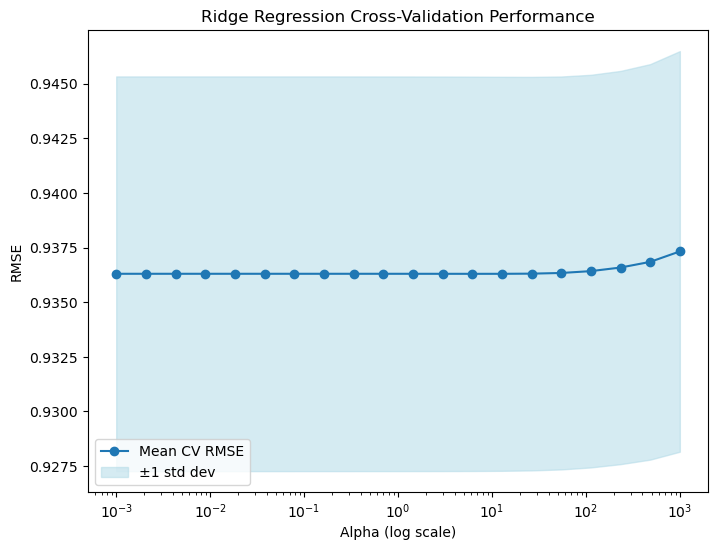

In [28]:
# Plot performance
plt.figure(figsize=(8,6))
plt.semilogx(alphas, mean_rmse, marker='o', label="Mean CV RMSE")
plt.fill_between(alphas,
                 mean_rmse - std_rmse,
                 mean_rmse + std_rmse,
                 color='lightblue', alpha=0.5, label="±1 std dev")

plt.xlabel("Alpha (log scale)")
plt.ylabel("RMSE")
plt.title("Ridge Regression Cross-Validation Performance")
plt.legend()
plt.show()